In [1]:
#Shrinkage method

In [2]:
import pandas as pd
import numpy as np

In [3]:
wine = pd.read_csv('/Users/chintanjikkar/Desktop/PACE/Fall 25/Predictive Analytics/codes/Data/winequality-white.csv',sep=';')
wine.columns = wine.columns.str.replace(' ', '_')

In [4]:
from sklearn.model_selection import train_test_split
X = wine.drop(['quality'], axis=1)
y = wine.quality
X_train, X_test, y_train, y_test = train_test_split(X,
                                                    y,
                                                    test_size=0.3, 
                                                    random_state=1031)

In [5]:
from sklearn.preprocessing import StandardScaler
scale = StandardScaler()
scale.fit(X_train)
X_train_scaled = scale.transform(X_train)
X_test_scaled = scale.transform(X_test)

In [6]:
from sklearn.linear_model import ElasticNet, ElasticNetCV
lasso = ElasticNetCV(l1_ratio=1,
                     cv=5,
                     random_state=1031)
lasso.fit(X_train_scaled, y_train)
best_alpha = lasso.alpha_
print('The best alpha is', best_alpha)

The best alpha is 0.0007618482984559628


In [7]:
#even with very large data set they are very efficient

In [8]:
lasso.alpha_

np.float64(0.0007618482984559628)

In [9]:
#Confirming the prev output

In [10]:
lasso.coef_

array([ 0.07249511, -0.18159976, -0.0045665 ,  0.44806669,  0.00155619,
        0.05971874, -0.        , -0.51990445,  0.12298285,  0.07532625,
        0.1898886 ])

In [11]:
X_train.columns

Index(['fixed_acidity', 'volatile_acidity', 'citric_acid', 'residual_sugar',
       'chlorides', 'free_sulfur_dioxide', 'total_sulfur_dioxide', 'density',
       'pH', 'sulphates', 'alcohol'],
      dtype='object')

In [12]:
pd.DataFrame(lasso.coef_).set_index(X_train.columns)

,0
fixed_acidity,0.072495
volatile_acidity,-0.181600
citric_acid,-0.004567
residual_sugar,0.448067
chlorides,0.001556
free_sulfur_dioxide,0.059719
total_sulfur_dioxide,-0.000000
density,-0.519904
pH,0.122983
sulphates,0.075326


In [13]:
alphas = lasso.alphas_
mse_path = lasso.mse_path_
mean_mse = np.mean(mse_path, axis=1)
std_mse = np.std(mse_path, axis=1)

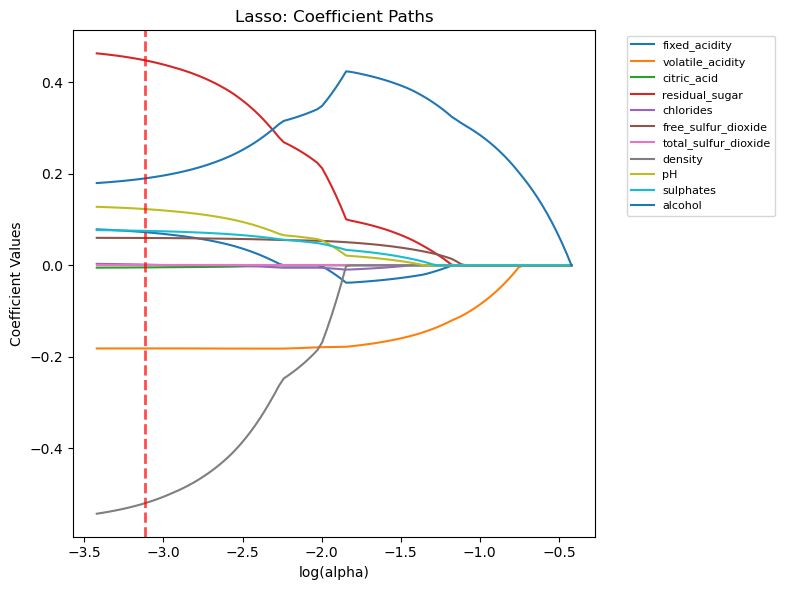

In [14]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 6))
feature_names = X_train.columns
coef_paths = []
for alpha in alphas:
    lasso_temp = ElasticNet(l1_ratio=1, alpha=alpha, random_state=1031, max_iter=2000)
    lasso_temp.fit(X_train_scaled, y_train)
    coef_paths.append(lasso_temp.coef_)
coef_paths = np.array(coef_paths)
# Plot of coefficient paths
for i, feature in enumerate(feature_names):
    plt.plot(np.log10(alphas), coef_paths[:, i], label=feature, linewidth=1.5)    
plt.axvline(x=np.log10(best_alpha), color='red', linestyle='--', alpha=0.7, linewidth=2)
plt.xlabel('log(alpha)')
plt.ylabel('Coefficient Values')
plt.title('Lasso: Coefficient Paths')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=8)
plt.tight_layout()
plt.show()

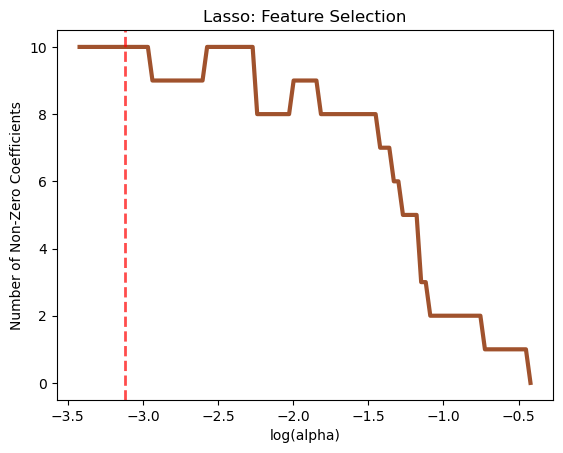

In [15]:
# Plot of number of non-zero coefficients vs alpha
non_zero_counts = np.sum(coef_paths != 0, axis=1)
plt.plot(np.log10(alphas), non_zero_counts, 'sienna', linewidth=3)
plt.axvline(x=np.log10(best_alpha), color='red', linestyle='--', alpha=0.7, linewidth=2)
plt.xlabel('log(alpha)')
plt.ylabel('Number of Non-Zero Coefficients')
plt.title('Lasso: Feature Selection')
plt.show()

In [16]:
from sklearn.decomposition import PCA
pca = PCA(n_components=5)
pca.fit(X_train_scaled)
X_train_pc = pca.transform(X_train_scaled)
X_test_pc =  pca.transform(X_test_scaled)
X_train_pc

array([[-0.6351008 , -1.53094122,  0.76911674,  4.89703295, -0.405477  ],
       [ 2.26844888, -1.55666487,  0.89818634, -0.70915726, -1.53108657],
       [ 1.31685614, -0.53855171, -0.73444566,  0.33361523, -0.52027253],
       ...,
       [ 0.8019643 ,  1.50280166,  1.07443231, -0.74208311,  0.40968636],
       [ 1.18977299,  2.0325778 , -0.65920222, -0.21492415, -0.05507088],
       [ 1.03016018,  0.33972773,  0.61365436,  0.27331317,  0.9521514 ]],
      shape=(3428, 5))

In [17]:
X_train_scaled.shape

(3428, 11)

In [18]:
X_train_pc.shape

(3428, 5)

In [19]:
#As you can see the number of components have been reduced from before

In [20]:
pd.DataFrame(X_train_pc).head()

,0,1,2,3,4
0,-0.635101,-1.530941,0.769117,4.897033,-0.405477
1,2.268449,-1.556665,0.898186,-0.709157,-1.531087
2,1.316856,-0.538552,-0.734446,0.333615,-0.520273
3,-2.693740,-0.411735,1.544918,-0.471308,1.472610
4,-0.984914,-0.882631,-0.133280,0.696665,-0.196665


In [21]:
#How much variance are we preserving how much good it is at doing what it does

In [22]:
pca.explained_variance_ratio_

array([0.29394217, 0.14288203, 0.11151051, 0.09306985, 0.0901216 ])

In [23]:
np.sum(pca.explained_variance_ratio_)

np.float64(0.7315261574501755)

In [24]:
#we will now try it with 5 
pca = PCA(n_components=5)
pca.fit(X_train_scaled)
X_train_pc = pca.transform(X_train_scaled)
X_test_pc =  pca.transform(X_test_scaled)

np.sum(pca.explained_variance_ratio_)

np.float64(0.7315261574501755)

In [25]:
#As number of components drop we lose more and more information
pca = PCA(n_components=8)
pca.fit(X_train_scaled)
X_train_pc = pca.transform(X_train_scaled)
X_test_pc =  pca.transform(X_test_scaled)

np.sum(pca.explained_variance_ratio_)

np.float64(0.9364357442997648)

In [26]:
#As number of components drop we lose more and more information
pca = PCA(n_components=3)
pca.fit(X_train_scaled)
X_train_pc = pca.transform(X_train_scaled)
X_test_pc =  pca.transform(X_test_scaled)

np.sum(pca.explained_variance_ratio_)

np.float64(0.5483347080679654)

In [27]:
#PCA will map of our features to components whose meaning will be lost but not essence
#it s either for prediction or inference
#if its prediction and the meaning is gone it doesnt matter as you are more interested to predict but it will be problematic if you are to infer that data

In [28]:
#Playdough analogy for the lasso model explanation
#11 colours of clay
#mis them all up to make 1 big ball
#split into 5 smaller balls
#each ball is now an amalgation of all the colours of the original balls and dough
#some might have more of one colours than the others but thats the charm of it

In [29]:
############### TREE MODELS #################

In [30]:
import pandas as pd
import numpy as np

houses = pd.read_csv('/Users/chintanjikkar/Desktop/PACE/Fall 25/Predictive Analytics/codes/Data/houses.csv')

X = houses.drop(['id', 'price', 'yr_built', 'yr_renovated'], axis = 1)
y = houses.price

from sklearn.model_selection import train_test_split
y_binned = pd.qcut(y, q = 100)
X_train, X_test, y_train, y_test = train_test_split(X, y, 
                                                   train_size=0.7,
                                                   random_state=617)

#pandas built on nump

In [31]:
from sklearn.tree import DecisionTreeRegressor

tree = DecisionTreeRegressor()

tree.fit(X_train, y_train)
tree.predict(X_train)

array([439950., 690000., 785000., ..., 538500., 397900., 327000.],
      shape=(15129,))

In [32]:
from sklearn.tree import DecisionTreeRegressor

tree = DecisionTreeRegressor(random_state=617,max_depth=2)

tree.fit(X_train, y_train)
y_pred = tree.predict(X_train)
y_pred_test = tree.predict(X_test)


In [33]:
from sklearn.metrics import root_mean_squared_error
print('Train RMSE:',root_mean_squared_error(y_train,y_pred))
print('Test RMSE:',root_mean_squared_error(y_test, y_pred_test))

Train RMSE: 268143.1620135497
Test RMSE: 265229.47129028453


In [34]:
tree = DecisionTreeRegressor(random_state=617,max_depth=4)

tree.fit(X_train, y_train)
y_pred = tree.predict(X_train)
y_pred_test = tree.predict(X_test)

print('Train RMSE:',root_mean_squared_error(y_train,y_pred))
print('Test RMSE:',root_mean_squared_error(y_test, y_pred_test))

Train RMSE: 222234.68175000354
Test RMSE: 225331.5182458686


In [35]:
tree = DecisionTreeRegressor(random_state=617,max_depth=6)

tree.fit(X_train, y_train)
y_pred = tree.predict(X_train)
y_pred_test = tree.predict(X_test)

print('Train RMSE:',root_mean_squared_error(y_train,y_pred))
print('Test RMSE:',root_mean_squared_error(y_test, y_pred_test))

Train RMSE: 192112.44333730685
Test RMSE: 207905.84199505672


In [36]:
tree = DecisionTreeRegressor(random_state=617,max_depth=7)

tree.fit(X_train, y_train)
y_pred = tree.predict(X_train)
y_pred_test = tree.predict(X_test)

print('Train RMSE:',root_mean_squared_error(y_train,y_pred))
print('Test RMSE:',root_mean_squared_error(y_test, y_pred_test))

Train RMSE: 181187.2871659464
Test RMSE: 211883.16217689382


In [37]:
tree = DecisionTreeRegressor(random_state=617,max_depth=8)

tree.fit(X_train, y_train)
y_pred = tree.predict(X_train)
y_pred_test = tree.predict(X_test)

print('Train RMSE:',root_mean_squared_error(y_train,y_pred))
print('Test RMSE:',root_mean_squared_error(y_test, y_pred_test))

Train RMSE: 170924.92011001377
Test RMSE: 207232.83168090417


In [38]:
# 8 is the max depth most optimal ie larger tree = max depth after which it inflects and starts to increase

In [39]:
tree = DecisionTreeRegressor(random_state=617,max_depth=9)

tree.fit(X_train, y_train)
y_pred = tree.predict(X_train)
y_pred_test = tree.predict(X_test)

print('Train RMSE:',root_mean_squared_error(y_train,y_pred))
print('Test RMSE:',root_mean_squared_error(y_test, y_pred_test))

Train RMSE: 159254.42765099875
Test RMSE: 210231.41564811446


In [40]:
#ECONOMETRTICIAN & MACHINE LEARNING TECHNICIAN HAVE DIFFERENT OPINIONS FOR THE ABOVE PHENOMENA

Train RMSE: 268143.1620135497
Test RMSE: 265229.47129028453


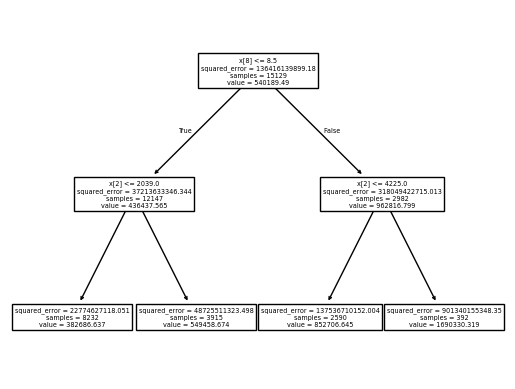

In [41]:
from sklearn.tree import plot_tree
tree = DecisionTreeRegressor(random_state=617,max_depth=2)

tree.fit(X_train, y_train)
y_pred = tree.predict(X_train)
y_pred_test = tree.predict(X_test)

print('Train RMSE:',root_mean_squared_error(y_train,y_pred))
print('Test RMSE:',root_mean_squared_error(y_test, y_pred_test))

plot_tree(tree);

Train RMSE: 243379.40639549663
Test RMSE: 245613.96549196943


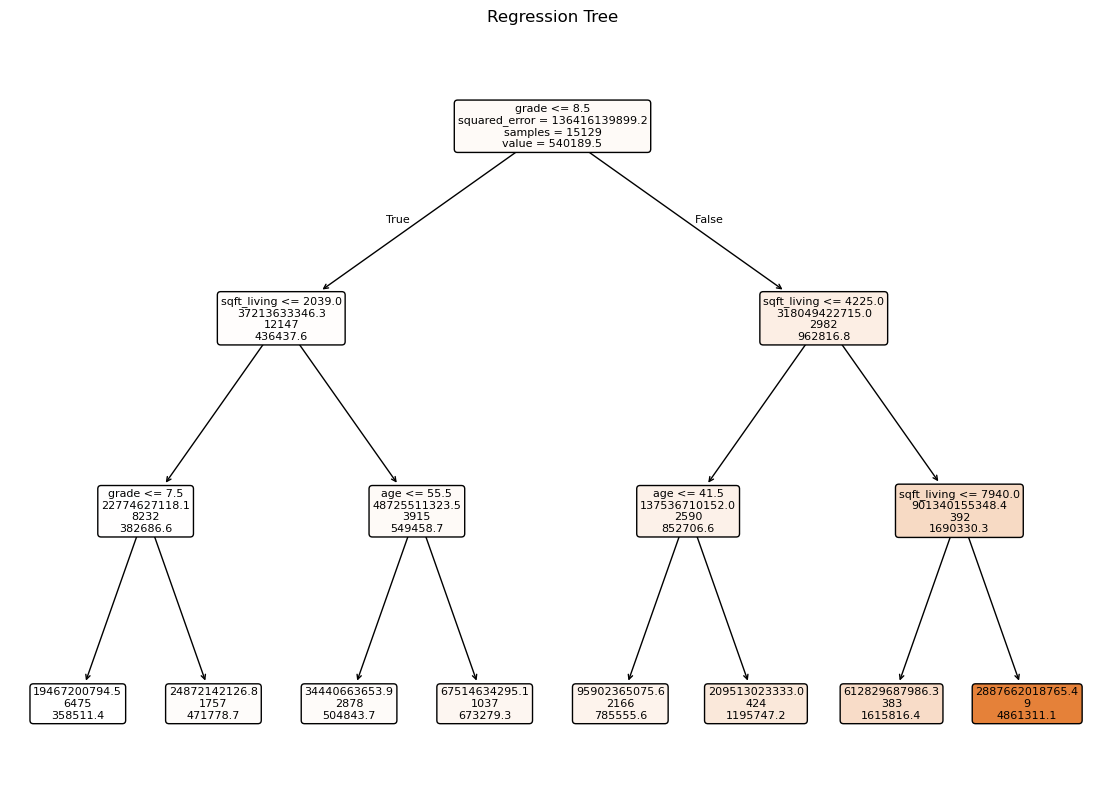

In [42]:
from sklearn.tree import plot_tree
tree = DecisionTreeRegressor(random_state=617,max_depth=3)

tree.fit(X_train, y_train)
y_pred = tree.predict(X_train)
y_pred_test = tree.predict(X_test)

print('Train RMSE:',root_mean_squared_error(y_train,y_pred))
print('Test RMSE:',root_mean_squared_error(y_test, y_pred_test))

from sklearn.tree import plot_tree

plt.figure(figsize=(14, 10))
plot_tree(tree, 
          feature_names=X.columns,
          label = 'root', 
          filled=True,
          fontsize=8,
          rounded = True, 
          precision = 1,
          node_ids=False)
plt.title("Regression Tree")
plt.show()

Train RMSE: 148100.70190795927
Test RMSE: 221662.71418439026


Text(0.5, 1.0, 'Regression Tree')

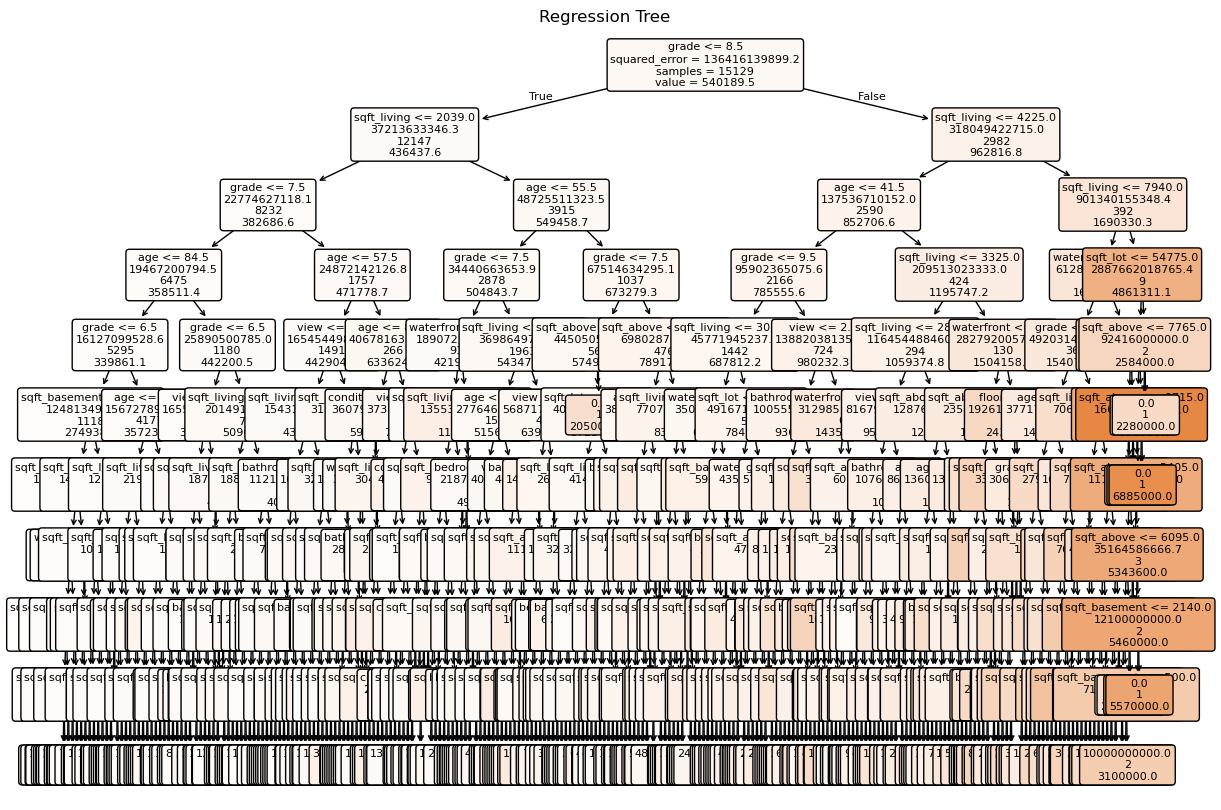

In [43]:
from sklearn.tree import plot_tree
tree = DecisionTreeRegressor(random_state=617,max_depth=10)

tree.fit(X_train, y_train)
y_pred = tree.predict(X_train)
y_pred_test = tree.predict(X_test)

print('Train RMSE:',root_mean_squared_error(y_train,y_pred))
print('Test RMSE:',root_mean_squared_error(y_test, y_pred_test))

from sklearn.tree import plot_tree

plt.figure(figsize=(14, 10))
plot_tree(tree, 
          feature_names=X.columns,
          label = 'root', 
          filled=True,
          fontsize=8,
          rounded = True, 
          precision = 1,
          node_ids=False)
plt.title("Regression Tree")

Train RMSE: 243379.40639549663
Test RMSE: 245613.96549196943


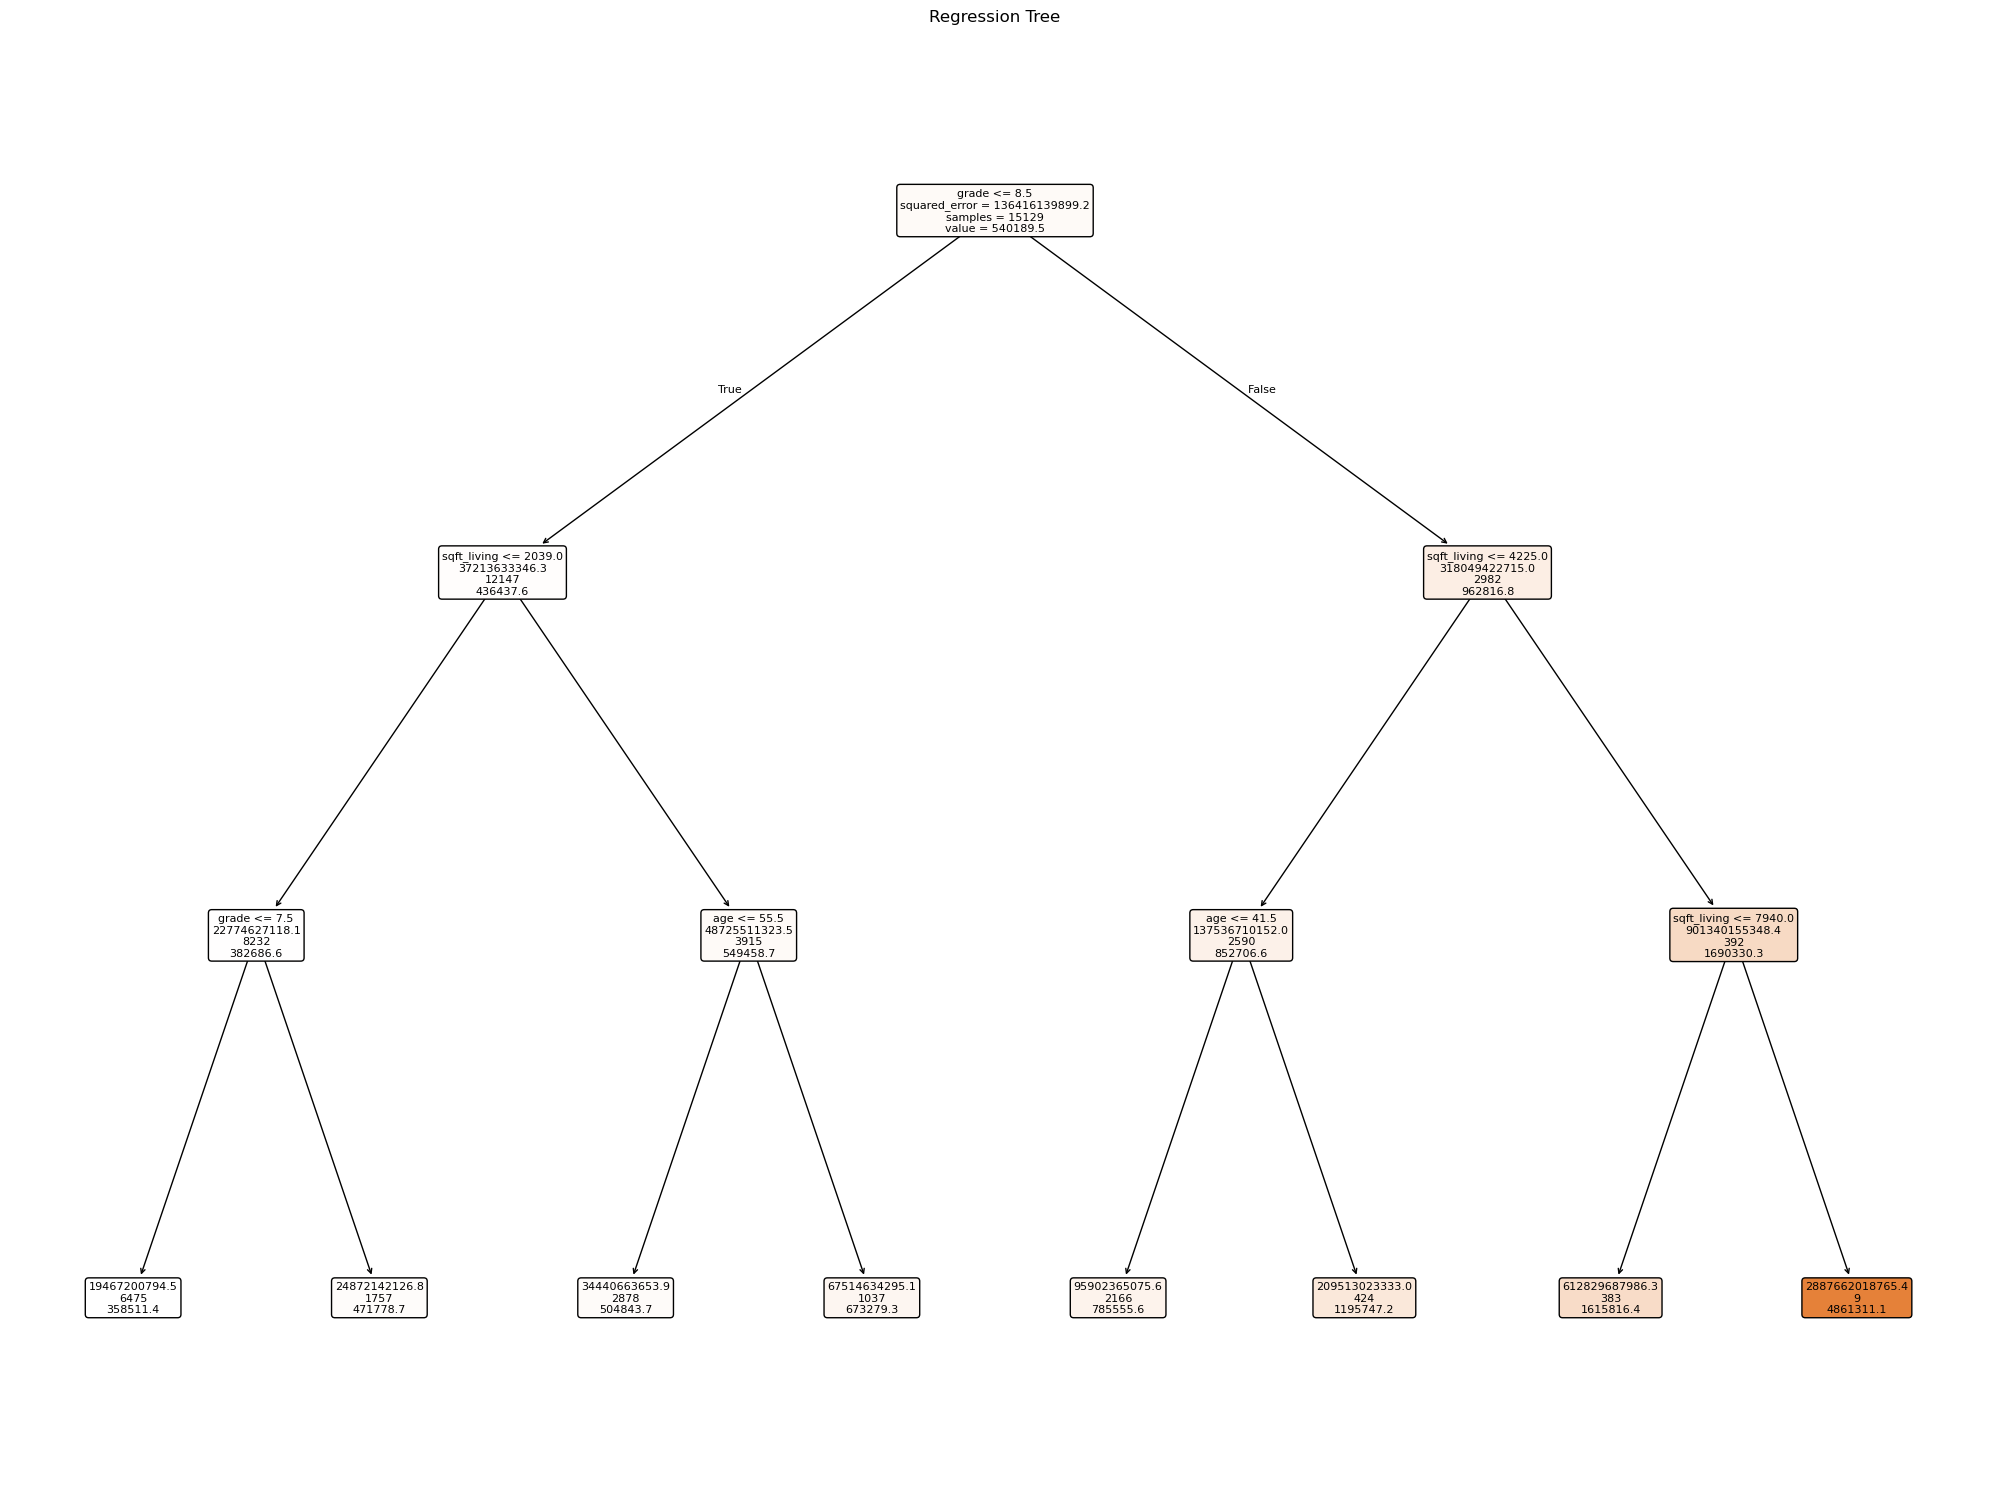

In [44]:
from sklearn.tree import plot_tree
tree = DecisionTreeRegressor(random_state=617, max_depth=3)

tree.fit(X_train, y_train)
y_pred = tree.predict(X_train)
y_pred_test = tree.predict(X_test)

print('Train RMSE:', root_mean_squared_error(y_train, y_pred))
print('Test RMSE:', root_mean_squared_error(y_test, y_pred_test))

from sklearn.tree import plot_tree

# Increased figure size from (14, 10) to (25, 20) to prevent overlapping
plt.figure(figsize=(20, 15))
plot_tree(tree, 
          feature_names=X.columns,
          label='root', 
          filled=True,
          fontsize=8,
          rounded=True, 
          precision=1,
          node_ids=False)
plt.title("Regression Tree")
plt.tight_layout()  # Added tight_layout to better use the figure space
plt.show()

In [45]:
dream_house = pd.DataFrame({'bedrooms':[4],
            'bathrooms':[3],
            'sqft_living':[6000],
            'sqft_lot':[12000],
            'floors':[1],
            'waterfront':[0],
            'view':[1],
            'condition':[10],
            'grade':[3],
            'sqft_above':[6000],
            'sqft_basement':[0],
            'age':[10]})

tree.predict(dream_house)

array([504843.66608756])

In [46]:
# the order of the variables used in the tree has the priority of the ones that it likes the most

In [47]:
dream_house = pd.DataFrame({'bedrooms':[4],
            'bathrooms':[3],
            'sqft_living':[6000],
            'sqft_lot':[12000],
            'floors':[1],
            'waterfront':[0],
            'view':[1],
            'condition':[10],
            'grade':[3],
            'sqft_above':[6000],
            'sqft_basement':[0],
            'age':[10]})

tree.predict(dream_house)
pd.DataFrame(tree.feature_importances_).set_index(X_train.columns)

,0
bedrooms,0.000000
bathrooms,0.000000
sqft_living,0.347088
sqft_lot,0.000000
floors,0.000000
waterfront,0.000000
view,0.000000
condition,0.000000
grade,0.583296
sqft_above,0.000000


In [48]:
#MAX DEPTH IS THE MODELS HYPERPARAMETER
#

In [53]:
%%time
from sklearn.model_selection import GridSearchCV
param_grid = {'max_depth': [2,3,4,5,6,7,8,9,10,11,12],
             'min_samples_leaf':[5, 10,20,40, 100, 150,200],
             'max_features': [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12]}
tune_tree = GridSearchCV(estimator=tree,
                         param_grid=param_grid, 
                         cv = 5,
                         scoring = 'neg_root_mean_squared_error', 
                         n_jobs = -1)
tune_tree.fit(X_train, y_train)

CPU times: user 637 ms, sys: 216 ms, total: 853 ms
Wall time: 10.6 s


,estimator,DecisionTreeR...dom_state=617)
,param_grid,"{'max_depth': [2, 3, ...], 'max_features': [1, 2, ...], 'min_samples_leaf': [5, 10, ...]}"
,scoring,'neg_root_mean_squared_error'
,n_jobs,-1
,refit,True
,cv,5
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,criterion,'squared_error'


In [51]:
%%time
tree = DecisionTreeRegressor(random_state=617)
param_grid = {'max_depth':[1,2,3,4,5,6]}
GridSearchCV(estimator=tree,
            param_grid=param_grid,
            scoring='neg_root_mean_squared_error',
            n_jobs=-1,
            cv=5,
            verbose=3)
tune_tree.fit(X_train,y_train)

CPU times: user 803 ms, sys: 304 ms, total: 1.11 s
Wall time: 9.37 s


,estimator,DecisionTreeR...dom_state=617)
,param_grid,"{'max_depth': [2, 3, ...], 'max_features': [1, 2, ...], 'min_samples_leaf': [5, 10, ...]}"
,scoring,'neg_root_mean_squared_error'
,n_jobs,-1
,refit,True
,cv,5
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,criterion,'squared_error'


In [59]:
pd.DataFrame(tune_tree.cv_results_)

,mean_fit_time,std_fit_time,mean_score_time,std_score_time,param_max_depth,param_max_features,param_min_samples_leaf,params,split0_test_score,split1_test_score,split2_test_score,split3_test_score,split4_test_score,mean_test_score,std_test_score,rank_test_score
0,0.011217,0.005574,0.002326,0.001704,1,1,10,"{'max_depth': 1, 'max_features': 1, 'min_sampl...",-264736.800432,-293795.163159,-315868.371240,-326613.008729,-316816.592002,-303565.987113,22186.784939,57
1,0.006326,0.004634,0.001001,0.000467,1,2,10,"{'max_depth': 1, 'max_features': 2, 'min_sampl...",-264736.800432,-293795.163159,-315868.371240,-326613.008729,-316816.592002,-303565.987113,22186.784939,57
2,0.002602,0.000714,0.000740,0.000328,1,3,10,"{'max_depth': 1, 'max_features': 3, 'min_sampl...",-264736.800432,-293795.163159,-315868.371240,-326613.008729,-316816.592002,-303565.987113,22186.784939,57
3,0.002618,0.000329,0.000695,0.000238,1,4,10,"{'max_depth': 1, 'max_features': 4, 'min_sampl...",-264736.800432,-293795.163159,-315868.371240,-326613.008729,-316816.592002,-303565.987113,22186.784939,57
4,0.002702,0.000177,0.000682,0.000115,1,5,10,"{'max_depth': 1, 'max_features': 5, 'min_sampl...",-264736.800432,-293795.163159,-315868.371240,-326613.008729,-316816.592002,-303565.987113,22186.784939,57
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
59,0.009711,0.000821,0.000977,0.000498,8,4,10,"{'max_depth': 8, 'max_features': 4, 'min_sampl...",-206594.517295,-223379.617181,-225499.770999,-229638.371609,-217435.806279,-220509.616673,7994.385665,9
60,0.010790,0.000390,0.000678,0.000027,8,5,10,"{'max_depth': 8, 'max_features': 5, 'min_sampl...",-199821.438332,-207960.267651,-231733.328383,-231577.599965,-215501.794492,-217318.885765,12713.247477,2
61,0.012981,0.000687,0.000838,0.000294,8,6,10,"{'max_depth': 8, 'max_features': 6, 'min_sampl...",-206042.597870,-216319.717241,-224900.338687,-244563.153279,-225360.550793,-223437.271574,12691.545998,14
62,0.015242,0.000840,0.000753,0.000036,8,7,10,"{'max_depth': 8, 'max_features': 7, 'min_sampl...",-197420.956255,-221590.774707,-220978.908772,-235292.507129,-218885.788959,-218833.787164,12178.702900,4


In [56]:
%%time
tree = DecisionTreeRegressor(random_state=617)
param_grid = {'max_depth':[1,2,3]}
GridSearchCV(estimator=tree,
            param_grid=param_grid,
            scoring='neg_root_mean_squared_error',
            n_jobs=-1,
            cv=5,
            verbose=3)
tune_tree.fit(X_train,y_train)

CPU times: user 601 ms, sys: 193 ms, total: 794 ms
Wall time: 9.21 s


,estimator,DecisionTreeR...dom_state=617)
,param_grid,"{'max_depth': [2, 3, ...], 'max_features': [1, 2, ...], 'min_samples_leaf': [5, 10, ...]}"
,scoring,'neg_root_mean_squared_error'
,n_jobs,-1
,refit,True
,cv,5
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,criterion,'squared_error'


In [57]:
%%time
tree = DecisionTreeRegressor(random_state=617)
param_grid = {'max_depth':[1,2,3,4,5,6,7,8]}
GridSearchCV(estimator=tree,
            param_grid=param_grid,
            scoring='neg_root_mean_squared_error',
            n_jobs=-1,
            cv=5,
            verbose=3)
tune_tree.fit(X_train,y_train)

CPU times: user 660 ms, sys: 201 ms, total: 861 ms
Wall time: 9.32 s


,estimator,DecisionTreeR...dom_state=617)
,param_grid,"{'max_depth': [2, 3, ...], 'max_features': [1, 2, ...], 'min_samples_leaf': [5, 10, ...]}"
,scoring,'neg_root_mean_squared_error'
,n_jobs,-1
,refit,True
,cv,5
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,criterion,'squared_error'


In [58]:
%%time
from sklearn.model_selection import GridSearchCV
param_grid = {'max_depth': [1,2,3,4,5,6,7,8],
             'min_samples_leaf':[10],
             'max_features': [1, 2, 3, 4, 5, 6, 7, 8]}
tune_tree = GridSearchCV(estimator=tree,
                         param_grid=param_grid, 
                         cv = 5,
                         scoring = 'neg_root_mean_squared_error', 
                         n_jobs = -1)
tune_tree.fit(X_train, y_train)

CPU times: user 190 ms, sys: 103 ms, total: 293 ms
Wall time: 734 ms


,estimator,DecisionTreeR...dom_state=617)
,param_grid,"{'max_depth': [1, 2, ...], 'max_features': [1, 2, ...], 'min_samples_leaf': [10]}"
,scoring,'neg_root_mean_squared_error'
,n_jobs,-1
,refit,True
,cv,5
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,criterion,'squared_error'


In [63]:
%%time
tree = DecisionTreeRegressor(random_state=617)
param_grid = {'ccp_alpha':[0,0.05,0.1,0.15,0.2]}
GridSearchCV(estimator=tree,
            param_grid=param_grid,
            scoring='neg_root_mean_squared_error',
            n_jobs=-1,
            cv=5,
            verbose=3)
tune_tree.fit(X_train,y_train)

CPU times: user 186 ms, sys: 159 ms, total: 345 ms
Wall time: 719 ms


,estimator,DecisionTreeR...dom_state=617)
,param_grid,"{'max_depth': [1, 2, ...], 'max_features': [1, 2, ...], 'min_samples_leaf': [10]}"
,scoring,'neg_root_mean_squared_error'
,n_jobs,-1
,refit,True
,cv,5
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,criterion,'squared_error'


In [64]:
pd.DataFrame(tune_tree.cv_results_)

,mean_fit_time,std_fit_time,mean_score_time,std_score_time,param_max_depth,param_max_features,param_min_samples_leaf,params,split0_test_score,split1_test_score,split2_test_score,split3_test_score,split4_test_score,mean_test_score,std_test_score,rank_test_score
0,0.003418,0.000576,0.001066,0.000168,1,1,10,"{'max_depth': 1, 'max_features': 1, 'min_sampl...",-264736.800432,-293795.163159,-315868.371240,-326613.008729,-316816.592002,-303565.987113,22186.784939,57
1,0.003218,0.000149,0.001075,0.000198,1,2,10,"{'max_depth': 1, 'max_features': 2, 'min_sampl...",-264736.800432,-293795.163159,-315868.371240,-326613.008729,-316816.592002,-303565.987113,22186.784939,57
2,0.002856,0.000463,0.000970,0.000252,1,3,10,"{'max_depth': 1, 'max_features': 3, 'min_sampl...",-264736.800432,-293795.163159,-315868.371240,-326613.008729,-316816.592002,-303565.987113,22186.784939,57
3,0.003913,0.000350,0.001042,0.000054,1,4,10,"{'max_depth': 1, 'max_features': 4, 'min_sampl...",-264736.800432,-293795.163159,-315868.371240,-326613.008729,-316816.592002,-303565.987113,22186.784939,57
4,0.003800,0.000773,0.001002,0.000221,1,5,10,"{'max_depth': 1, 'max_features': 5, 'min_sampl...",-264736.800432,-293795.163159,-315868.371240,-326613.008729,-316816.592002,-303565.987113,22186.784939,57
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
59,0.009019,0.000393,0.000899,0.000321,8,4,10,"{'max_depth': 8, 'max_features': 4, 'min_sampl...",-206594.517295,-223379.617181,-225499.770999,-229638.371609,-217435.806279,-220509.616673,7994.385665,9
60,0.011210,0.000365,0.000689,0.000024,8,5,10,"{'max_depth': 8, 'max_features': 5, 'min_sampl...",-199821.438332,-207960.267651,-231733.328383,-231577.599965,-215501.794492,-217318.885765,12713.247477,2
61,0.014126,0.000961,0.000711,0.000047,8,6,10,"{'max_depth': 8, 'max_features': 6, 'min_sampl...",-206042.597870,-216319.717241,-224900.338687,-244563.153279,-225360.550793,-223437.271574,12691.545998,14
62,0.014077,0.000455,0.000694,0.000020,8,7,10,"{'max_depth': 8, 'max_features': 7, 'min_sampl...",-197420.956255,-221590.774707,-220978.908772,-235292.507129,-218885.788959,-218833.787164,12178.702900,4


In [75]:
import numpy as np
np.arange(0.17,0.22,0.001)

array([0.17 , 0.171, 0.172, 0.173, 0.174, 0.175, 0.176, 0.177, 0.178,
       0.179, 0.18 , 0.181, 0.182, 0.183, 0.184, 0.185, 0.186, 0.187,
       0.188, 0.189, 0.19 , 0.191, 0.192, 0.193, 0.194, 0.195, 0.196,
       0.197, 0.198, 0.199, 0.2  , 0.201, 0.202, 0.203, 0.204, 0.205,
       0.206, 0.207, 0.208, 0.209, 0.21 , 0.211, 0.212, 0.213, 0.214,
       0.215, 0.216, 0.217, 0.218, 0.219])

In [79]:
%%time
tree = DecisionTreeRegressor(random_state=617)
param_grid = {'ccp_alpha':np.arange(0.17,0.22,0.001),
             'max_depth':[4,5,6,7,8,9]}
GridSearchCV(estimator=tree,
            param_grid=param_grid,
            scoring='neg_root_mean_squared_error',
            n_jobs=-1,
            cv=5,
            verbose=3)
tune_tree.fit(X_train,y_train)

CPU times: user 202 ms, sys: 219 ms, total: 421 ms
Wall time: 2.81 s


,estimator,DecisionTreeR...dom_state=617)
,param_grid,"{'max_depth': [1, 2, ...], 'max_features': [1, 2, ...], 'min_samples_leaf': [10]}"
,scoring,'neg_root_mean_squared_error'
,n_jobs,-1
,refit,True
,cv,5
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,criterion,'squared_error'


In [80]:
pd.DataFrame(tune_tree.cv_results_).sort_values('mean_test_score', ascending=False)

,mean_fit_time,std_fit_time,mean_score_time,std_score_time,param_max_depth,param_max_features,param_min_samples_leaf,params,split0_test_score,split1_test_score,split2_test_score,split3_test_score,split4_test_score,mean_test_score,std_test_score,rank_test_score
63,0.016190,0.000692,0.000655,0.000031,8,8,10,"{'max_depth': 8, 'max_features': 8, 'min_sampl...",-193630.793608,-211386.820524,-223048.399859,-232849.418809,-207456.222478,-213674.331056,13425.335217,1
60,0.010664,0.000225,0.000687,0.000025,8,5,10,"{'max_depth': 8, 'max_features': 5, 'min_sampl...",-199821.438332,-207960.267651,-231733.328383,-231577.599965,-215501.794492,-217318.885765,12713.247477,2
58,0.006506,0.000433,0.000689,0.000025,8,3,10,"{'max_depth': 8, 'max_features': 3, 'min_sampl...",-206016.130681,-210695.230878,-231305.525436,-223940.591862,-216831.137902,-217757.723352,9059.505100,3
62,0.016622,0.002428,0.000768,0.000080,8,7,10,"{'max_depth': 8, 'max_features': 7, 'min_sampl...",-197420.956255,-221590.774707,-220978.908772,-235292.507129,-218885.788959,-218833.787164,12178.702900,4
55,0.017077,0.002388,0.000831,0.000255,7,8,10,"{'max_depth': 7, 'max_features': 8, 'min_sampl...",-202202.598869,-219198.132466,-226011.061403,-233650.618369,-215908.392770,-219394.160775,10533.458725,5
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1,0.006676,0.007650,0.001671,0.001585,1,2,10,"{'max_depth': 1, 'max_features': 2, 'min_sampl...",-264736.800432,-293795.163159,-315868.371240,-326613.008729,-316816.592002,-303565.987113,22186.784939,57
5,0.003922,0.001353,0.001170,0.000408,1,6,10,"{'max_depth': 1, 'max_features': 6, 'min_sampl...",-264736.800432,-293795.163159,-315868.371240,-326613.008729,-316816.592002,-303565.987113,22186.784939,57
6,0.003769,0.000412,0.000762,0.000198,1,7,10,"{'max_depth': 1, 'max_features': 7, 'min_sampl...",-264736.800432,-293795.163159,-315868.371240,-326613.008729,-316816.592002,-303565.987113,22186.784939,57
7,0.003719,0.000678,0.000901,0.000359,1,8,10,"{'max_depth': 1, 'max_features': 8, 'min_sampl...",-264736.800432,-293795.163159,-315868.371240,-326613.008729,-316816.592002,-303565.987113,22186.784939,57


In [81]:
tune_tree.best_params_, tune_tree.best_score_

({'max_depth': 8, 'max_features': 8, 'min_samples_leaf': 10},
 np.float64(-213674.33105550436))

In [ ]:
from sklearn.tree import plot_tree
best_tree = DecisionTreeRegressor(ccp_alpha=0.17, max_depth=6, random_state=617)
best_tree.fit(X_train,y_train)
pd.DataFrame(best_tree.feature_importances_).set_index()

In [82]:
from sklearn.linear_model import LinearRegression
reg = LinearRegression()
reg.fit(X_train,y_train)
pred_train = reg.predict(X_train)
pred_test = reg.predict(X_test)

from sklearn.metrics import root_mean_squared_error
root_mean_squared_error(y_train, pred_train), root_mean_squared_error(y_test, pred_test)

(216982.4273895381, 215229.9728795764)

In [83]:
#Running a reg tree with max_depth 3

In [86]:
from sklearn.tree import DecisionTreeRegressor
from sklearn.tree import plot_tree

tree = DecisionTreeRegressor(random_state=617, max_depth=3)

tree.fit(X_train, y_train)
pred_train = tree.predict(X_train)
pred_test = tree.predict(X_test)

print('Train RMSE:', root_mean_squared_error(y_train, pred_train))
print('Test RMSE:', root_mean_squared_error(y_test, pred_test))

Train RMSE: 243379.40639549663
Test RMSE: 245613.96549196943


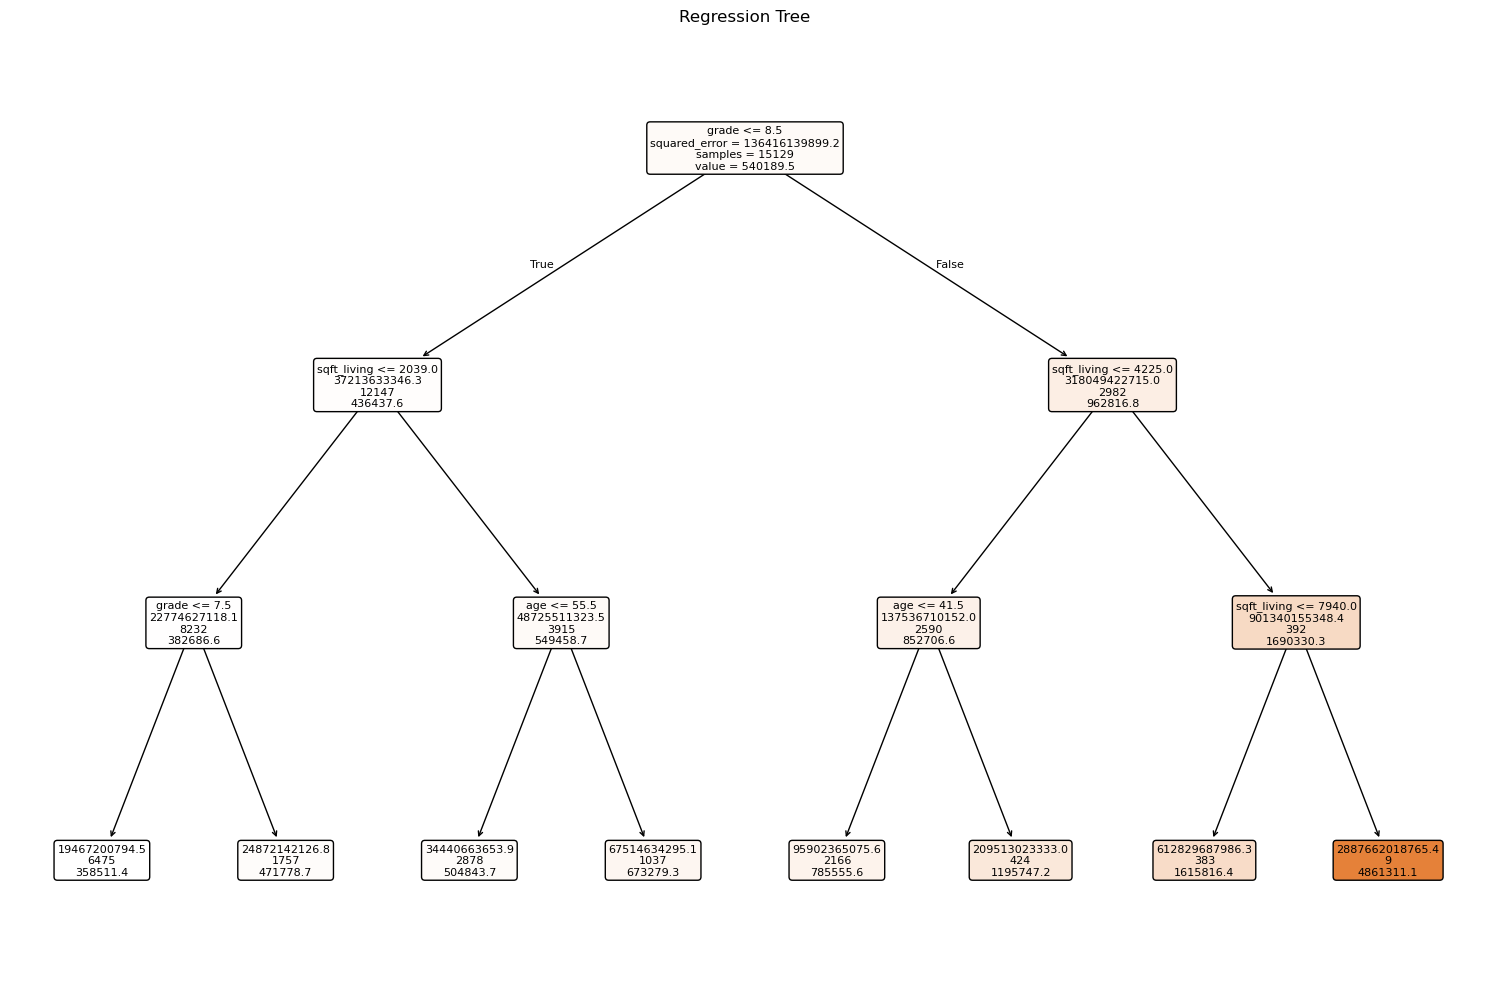

In [88]:
from sklearn.tree import plot_tree

plt.figure(figsize=(15, 10))
plot_tree(tree, 
          feature_names=X.columns,
          label='root', 
          filled=True,
          fontsize=8,
          rounded=True, 
          precision=1,
          node_ids=False)
plt.title("Regression Tree")
plt.tight_layout()  # Added tight_layout to better use the figure space
plt.show()

In [98]:
from sklearn.ensemble import VotingRegressor

vc = VotingRegressor([('LinReg', reg), ('RegTree', tree)],n_jobs=-1)
vc.fit(X_train, y_train)
vc_train = vc.predict(X_train)
vc_test = vc.predict(X_test)

print('Train RMSE:', root_mean_squared_error(y_train, vc_train))
print('Test RMSE:', root_mean_squared_error(y_test, vc_test))

Train RMSE: 214020.60288119756
Test RMSE: 215596.84507302847


In [99]:
tree2 = DecisionTreeRegressor(random_state=617, max_depth=4)

from sklearn.ensemble import VotingRegressor

vc = VotingRegressor([('LinReg', reg), ('RegTree', tree), ('RegTree2', tree2)],n_jobs=-1)
vc.fit(X_train, y_train)
vc_train = vc.predict(X_train)
vc_test = vc.predict(X_test)

print('Train RMSE:', root_mean_squared_error(y_train, vc_train))
print('Test RMSE:', root_mean_squared_error(y_test, vc_test))

Train RMSE: 211890.33271246756
Test RMSE: 214849.86988154252


In [101]:
tree2 = DecisionTreeRegressor(random_state=617, max_depth=4)

tree3 = DecisionTreeRegressor(random_state=617, max_depth=5)

from sklearn.ensemble import VotingRegressor

vc = VotingRegressor([('LinReg', reg), ('RegTree', tree), ('RegTree2', tree2), ('RegTree3', tree3)],n_jobs=-1)
vc.fit(X_train, y_train)
vc_train = vc.predict(X_train)
vc_test = vc.predict(X_test)

print('Train RMSE:', root_mean_squared_error(y_train, vc_train))
print('Test RMSE:', root_mean_squared_error(y_test, vc_test))

Train RMSE: 207194.6011676671
Test RMSE: 213163.70473713457


In [103]:
df = pd.DataFrame({'id':[1,2,3,4,5],'Value':[1,13,52,7,69]})
df

,id,Value
0,1,1
1,2,13
2,3,52
3,4,7
4,5,69


In [119]:
df.sample(n=1)

,id,Value
4,5,69


In [121]:
df.sample(n=3, replace=True)

,id,Value
2,3,52
4,5,69
0,1,1


In [122]:
from sklearn.ensemble import BaggingRegressor
bag = BaggingRegressor(n_estimators=100, random_state=617)

bag.fit(X_train, y_train)
bag_train = bag.predict(X_train)
bag_test = bag.predict(X_test)

print('Train RMSE:', root_mean_squared_error(y_train, bag_train))
print('Test RMSE:', root_mean_squared_error(y_test, bag_test))

Train RMSE: 73609.43166592013
Test RMSE: 194098.75108208347


In [124]:
%%time
from sklearn.ensemble import BaggingRegressor
bag = BaggingRegressor(n_estimators=1000, random_state=617)

bag.fit(X_train, y_train)
bag_train = bag.predict(X_train)
bag_test = bag.predict(X_test)

print('Train RMSE:', root_mean_squared_error(y_train, bag_train))
print('Test RMSE:', root_mean_squared_error(y_test, bag_test))

Train RMSE: 71436.34443231685
Test RMSE: 193273.32280508426
CPU times: user 42.8 s, sys: 494 ms, total: 43.3 s
Wall time: 43.4 s


In [125]:
%%time
from sklearn.ensemble import BaggingRegressor
bag = BaggingRegressor(n_estimators=10000, random_state=617)

bag.fit(X_train, y_train)
bag_train = bag.predict(X_train)
bag_test = bag.predict(X_test)

print('Train RMSE:', root_mean_squared_error(y_train, bag_train))
print('Test RMSE:', root_mean_squared_error(y_test, bag_test))

KeyboardInterrupt: 